# Image Processing: Week 1 – Image Representation, Basic Operations, Geometric Transformations, Visual Annotations

Minggu ini kita akan mempelajari konsep fundamental dalam **pengolahan citra digital** dengan fokus pada representasi citra sebagai data, operasi dasar, transformasi geometris, serta anotasi visual. Teknik-teknik ini merupakan fondasi penting sebelum masuk ke analisis citra tingkat lanjut.

**Tujuan Pembelajaran:**
Peserta menguasai representasi citra, mampu melakukan manipulasi geometris (memutar, menggeser, mengubah skala), dan dapat menambahkan anotasi visual (teks, bentuk) pada citra sebagai dasar visualisasi. 

*This module is inspired by the development of last semester’s materials.* 

## Pengantar

### Apa itu Gambar?

Secara sederhana, **gambar digital** adalah matriks berisi nilai piksel.  
- Setiap **piksel** mewakili warna tertentu.  
- Intensitas warna ditentukan oleh nilai numerik pada piksel tersebut.  
- Gambar berwarna umumnya direpresentasikan dalam **3 channel warna**: **Merah (R), Hijau (G), dan Biru (B)**.  

Bayangkan gambar seperti lembar kerja **Microsoft Excel**: ada baris dan kolom. Bedanya, setiap sel tidak hanya berisi angka biasa, melainkan nilai yang menentukan warna. Hasil gabungan ribuan hingga jutaan piksel inilah yang membentuk sebuah citra digital.

---

### Kenapa teknik klasik pengolahan citra masih relevan?

Meskipun teknologi modern sudah dipenuhi dengan **deep learning** dan **AI**, teknik klasik pengolahan citra masih memiliki peran penting karena:  

1. **Dasar dari Computer Vision**  
   – Banyak algoritma modern tetap menggunakan operasi dasar citra (rotasi, cropping, filtering) sebagai preprocessing.  

2. **Lebih cepat & ringan**  
   – Transformasi sederhana dapat dilakukan jauh lebih efisien tanpa harus melibatkan model besar.  

3. **Mudah dijelaskan & diajarkan**  
   – Konsep piksel, transformasi, dan anotasi adalah pintu masuk untuk memahami sistem visual komputer yang lebih kompleks.  

---

### Contoh Teknik Klasik Pengolahan Citra

Beberapa teknik klasik yang masih banyak digunakan hingga sekarang antara lain:  

- *Filtering*: smoothing (blur), sharpening, edge detection (misalnya Sobel, Canny).  
- *Thresholding*: mengubah gambar ke biner untuk segmentasi objek sederhana.  
- *Morphological Operations*: dilasi, erosi, opening, closing untuk memperbaiki hasil segmentasi.  
- *Geometric Transformations*: translasi (geser), rotasi, scaling (ubah skala), flipping.  
- *Color Space Conversion*: RGB ↔ Grayscale ↔ HSV ↔ LAB.  
- *Histogram Analysis*: equalization, contrast stretching.  
- *Region of Interest (ROI)*: cropping dan masking pada bagian tertentu gambar.  
- *Annotation Tools*: menggambar kotak, lingkaran, atau teks pada gambar.  

---

### Aplikasi di Dunia Nyata

- *Computer Vision*: preprocessing gambar sebelum training model deteksi atau klasifikasi.  
- *Medical Imaging*: transformasi & anotasi hasil radiologi untuk diagnosis.  
- *Document Analysis*: penandaan, thresholding, dan cropping pada dokumen hasil scan.  
- *Robotics & Navigation*: koreksi orientasi citra untuk persepsi visual robot.  
- *Multimedia & Design*: menambahkan teks, bentuk, atau filter untuk editing foto dan presentasi.  

---

*Sebelum lanjut, kita coba import library yang akan kita butuhkan dulu*

In [180]:
# Import library yang dibutuhkan
import numpy as np  # Untuk operasi numerik dan manipulasi array
import matplotlib.pyplot as plt  # Untuk visualisasi gambar
import cv2  # OpenCV: library utama untuk pengolahan citra dan aplikasi terkait
import os  # Untuk operasi file dan path

# Cek versi library yang diinstal
print(f"Versi numpy: {np.__version__}")
print(f"Versi matplotlib: {plt.matplotlib.__version__}")
print(f"Versi OpenCV: {cv2.__version__}")

Versi numpy: 2.2.6
Versi matplotlib: 3.10.6
Versi OpenCV: 4.12.0


**Penjelasan:**
- `numpy` adalah library yang digunakan untuk operasi matriks
- `matplotlib` adalah library yang digunakan untuk plotting
- `cv2` adalah library `opencv` yang digunakan untuk membaca, menulis, dan memproses gambar
- `os` adalah library yang digunakan untuk berinteraksi dengan sistem operasi

# Konsep 1: Citra Sebagai Data

Citra digital adalah matriks dua/atau tiga dimensi yang berisi nilai piksel.
- **Resolusi:** jumlah piksel (lebar x tinggi)
- **Color space:** RGB (warna), Grayscale (abu-abu), HSV (hue, saturation, value)

Setiap piksel pada gambar warna memiliki 3 channel (R, G, B). Pada grayscale hanya 1 channel.

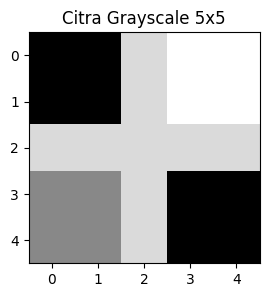

In [181]:
# Demo: Memuat, menampilkan, dan menyimpan citra
numpy_img_1ch = np.array([
    [0,   0,   128, 150, 150],
    [0,   0,   128, 150, 150],
    [128, 128, 128, 128, 128],
    [80,  80,  128,   0,   0],
    [80,  80,  128,   0,   0],
], dtype=np.uint8)

# Tampilkan citra grayscale
plt.figure(figsize=(3,3))
plt.imshow(numpy_img_1ch, cmap='gray')
plt.title("Citra Grayscale 5x5")
plt.show()

**Pertanyaan:**
- Mengapa kita perlu menuliskan `cmap='gray'` pada `imshow`?
- Apa maksud dari `dtype=np.uint8`?

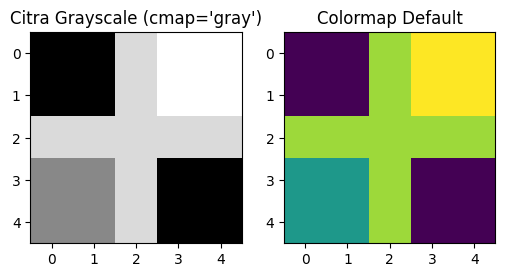

In [182]:
# Jawaban:
fig, axs = plt.subplots(1, 2, figsize=(6,3))

# Grayscale dengan cmap
axs[0].imshow(numpy_img_1ch, cmap='gray')
axs[0].set_title("Citra Grayscale (cmap='gray')")


axs[1].imshow(numpy_img_1ch)
axs[1].set_title("Colormap Default")

plt.show()


Channel Merah: 
[[  0   0 255   0 255]
 [  0   0 255   0   0]
 [255 255 255 255 255]
 [  0   0 255   0   0]
 [  0   0 255   0   0]]
Channel Hijau: 
[[255 255   0 255 255]
 [255 255   0 255 255]
 [  0   0   0   0   0]
 [255 255   0 255 255]
 [255 255   0 255 255]]
Channel Biru: 
[[  0   0   0   0 255]
 [  0   0   0   0   0]
 [  0   0   0   0   0]
 [  0   0   0   0   0]
 [  0   0   0   0   0]]


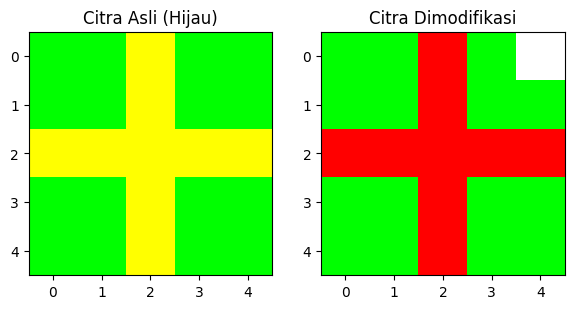

In [183]:
# Belajar memodifikasi piksel
# Buat citra 5x5 RGB
numpy_img_rgb = np.zeros((5, 5, 3), dtype=np.uint8)

# Set background hijau
numpy_img_rgb[:, :] = [0, 255, 0]

# Set kuning ke tengah citra
numpy_img_rgb[2, :] = [255, 255, 0]
numpy_img_rgb[:, 2] = [255, 255, 0]

# Salin untuk modifikasi
numpy_img_rgb_modified = numpy_img_rgb.copy()

# Buat plus merah di baris & kolom ke-2
numpy_img_rgb_modified[2, :] = [255, 0, 0]   
numpy_img_rgb_modified[:, 2] = [255, 0, 0]  

# Tambahkan titik putih di koordinat (0,4)
numpy_img_rgb_modified[0, 4] = [255, 255, 255]

# Tampilkan channel numeriknya
print(f"Channel Merah: \n{numpy_img_rgb_modified[:, :, 0]}")
print(f"Channel Hijau: \n{numpy_img_rgb_modified[:, :, 1]}")
print(f"Channel Biru: \n{numpy_img_rgb_modified[:, :, 2]}")

# Plot berdampingan
fig, axs = plt.subplots(1, 2, figsize=(6, 3))

axs[0].imshow(numpy_img_rgb)  # asli hijau
axs[0].set_title("Citra Asli (Hijau)")

axs[1].imshow(numpy_img_rgb_modified) 
axs[1].set_title("Citra Dimodifikasi")

plt.tight_layout()
plt.show()

# Praktik 1 (Hands-On): Operasi Dasar Citra

Pada sesi ini, kita akan melakukan muat gambar, menampilkan, *resizing, cropping,* konversi warna, dan memisahkan channel warna.

### 1. Load (Memuat Gambar)
Untuk memuat gambar, kita menggunakan fungsi `cv2.imread()` dari OpenCV. Fungsi ini membaca gambar dari path yang diberikan dan mengembalikannya sebagai array numpy. Path gambar disimpan dalam variabel `img_path`. Setelah gambar dimuat, kita dapat menampilkannya menggunakan `matplotlib`.


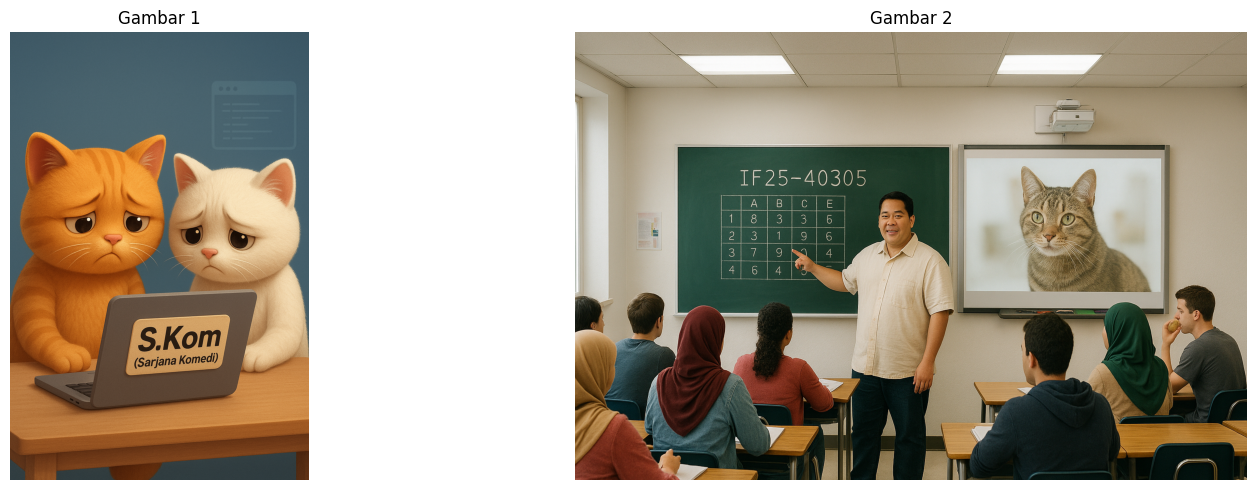

In [184]:
# Path gambar
img_path = os.path.join(os.getcwd(), 'data', 'sample1.png')
img2_path = os.path.join(os.getcwd(), 'data', 'sample2.png')

# Baca gambar
img = cv2.imread(img_path)
img2 = cv2.imread(img2_path)

# Konversi BGR → RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

# Plot berdampingan
fig, axs = plt.subplots(1, 2, figsize=(17, 5))

axs[0].imshow(img_rgb)
axs[0].set_title('Gambar 1')
axs[0].axis('off')

axs[1].imshow(img2_rgb)
axs[1].set_title('Gambar 2')
axs[1].axis('off')

plt.tight_layout()
plt.show()

**Pertanyaan:** Mengapa kita harus melakukan `cv2.cvtColor cv2.COLOR_BGR2RGB`?

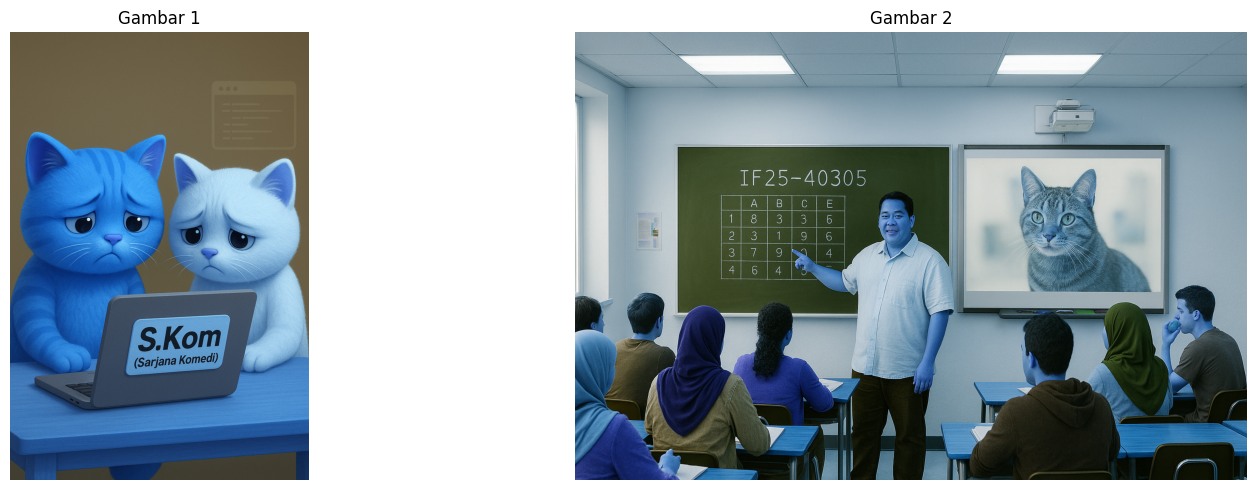

In [185]:
# Load gambar original tanpa cvtColor
img_bgr = cv2.imread(img_path)
img2_bgr = cv2.imread(img2_path)

fig, axs = plt.subplots(1, 2, figsize=(17, 5))

axs[0].imshow(img_bgr)
axs[0].set_title('Gambar 1')
axs[0].axis('off')

axs[1].imshow(img2_bgr)
axs[1].set_title('Gambar 2')
axs[1].axis('off')

plt.tight_layout()
plt.show()

### 2. Resize (Mengubah Ukuran Gambar)

Resize adalah proses **mengubah dimensi gambar** sesuai kebutuhan. Proses ini sering dilakukan untuk:

- 📉 Mengurangi ukuran file gambar  
- 🖥️ Menyesuaikan dengan resolusi layar atau halaman web  
- 🤖 Normalisasi ukuran input untuk model pembelajaran mesin  

**Cara Kerja:**
- Fungsi utama: `cv2.resize()`
- Parameter utama: `(width, height)` dalam bentuk tuple
- Pemilihan **metode interpolasi** berpengaruh pada kualitas hasil:
  - `cv2.INTER_LINEAR` → default, baik untuk memperbesar
  - `cv2.INTER_AREA` → terbaik untuk memperkecil
  - `cv2.INTER_CUBIC` dan `cv2.INTER_LANCZOS4` → kualitas tinggi, lebih halus untuk memperbesar


Shape img2_rgb: (1024, 1536, 3)
Tinggi gambar: 1024 piksel
Lebar gambar: 1536 piksel
Jumlah channel: 3 (RGB)


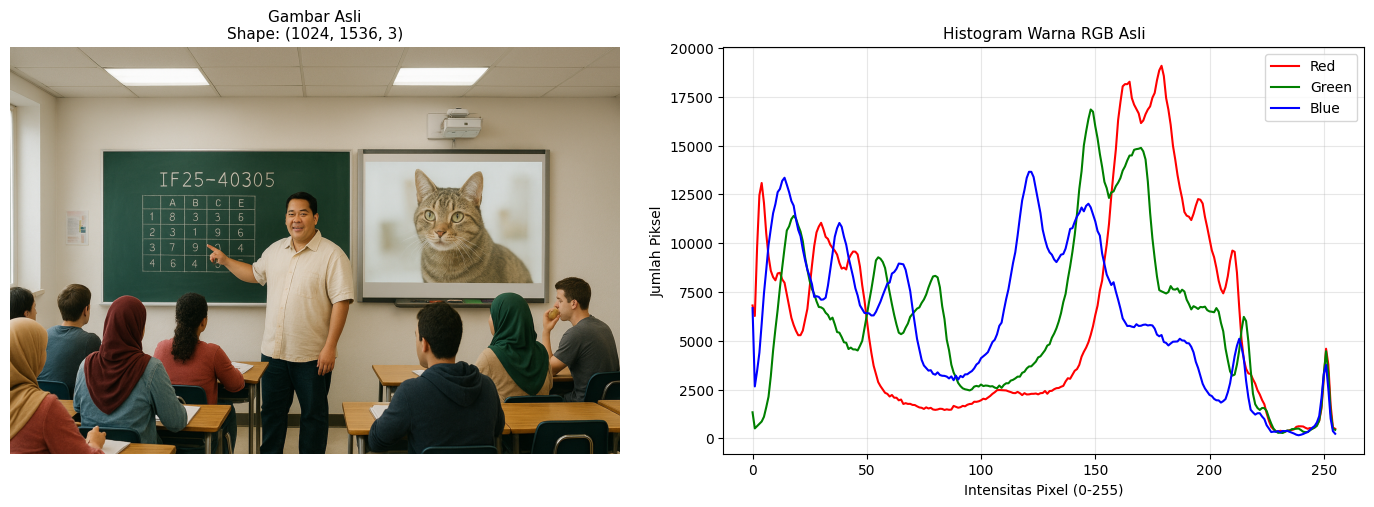

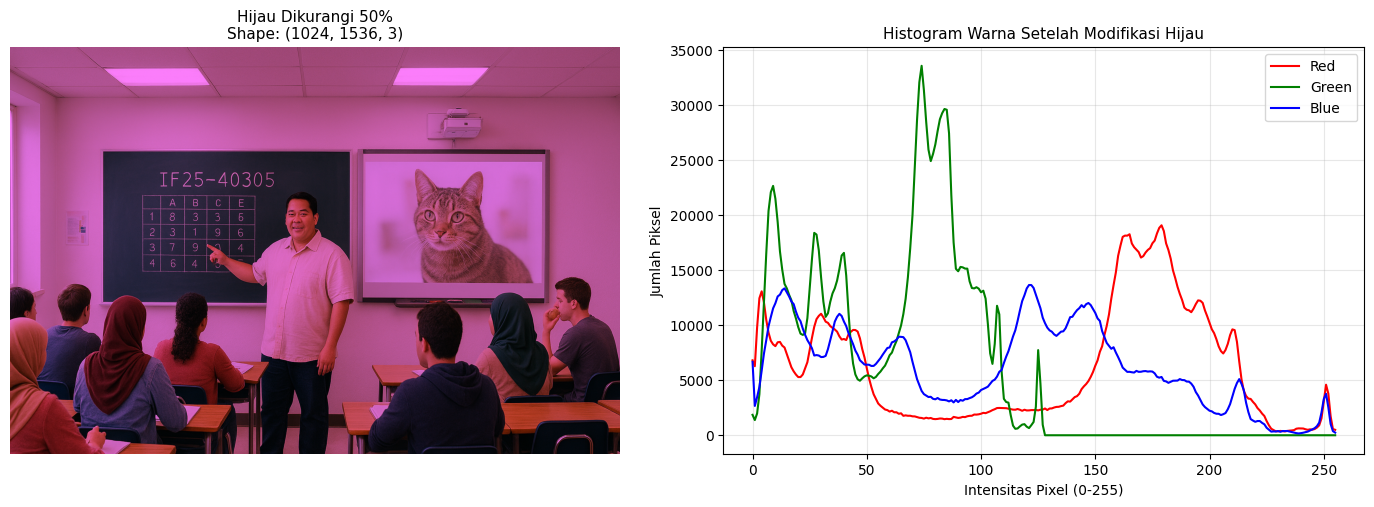


=== Penjelasan cv2.calcHist ===
cv2.calcHist([gambar], [channel], mask, [bins], [range])
- [gambar]: gambar input dalam list
- [channel]: channel yang ingin dihitung (0=R, 1=G, 2=B)
- mask: None berarti semua piksel dihitung
- [bins]: jumlah interval histogram (256 untuk 0-255)
- [range]: rentang nilai piksel [0,256)


In [186]:
# Mengecek shape dari gambar
print("Shape img2_rgb:", img2_rgb.shape)  # (tinggi, lebar, channel)
print("Tinggi gambar:", img2_rgb.shape[0], "piksel")
print("Lebar gambar:", img2_rgb.shape[1], "piksel")
print("Jumlah channel:", img2_rgb.shape[2], "(RGB)")

# Tampilkan gambar + histogram dalam 1 layout
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Gambar asli
axs[0].imshow(img2_rgb)
axs[0].set_title(f"Gambar Asli\nShape: {img2_rgb.shape}", fontsize=11)
axs[0].axis('off')

# Histogram RGB asli
colors = ('r','g','b')
labels = ('Red','Green','Blue')
for i, (col, label) in enumerate(zip(colors, labels)):
    hist = cv2.calcHist([img2_rgb], [i], None, [256], [0,256])
    axs[1].plot(hist, color=col, label=label)

axs[1].set_title("Histogram Warna RGB Asli", fontsize=11)
axs[1].set_xlabel("Intensitas Pixel (0-255)")
axs[1].set_ylabel("Jumlah Piksel")
axs[1].legend()
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Modifikasi: Kurangi intensitas warna hijau (G) menjadi setengah
img2_mod = img2_rgb.copy()
img2_mod[:,:,1] = (img2_mod[:,:,1] * 0.5).astype(np.uint8)

# Tampilkan gambar hasil modifikasi
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Gambar hasil modifikasi
axs[0].imshow(img2_mod)
axs[0].set_title("Hijau Dikurangi 50%\nShape: {}".format(img2_mod.shape), fontsize=11)
axs[0].axis('off')

# Histogram setelah modifikasi
for i, (col, label) in enumerate(zip(colors, labels)):
    hist = cv2.calcHist([img2_mod], [i], None, [256], [0,256])
    axs[1].plot(hist, color=col, label=label)

axs[1].set_title("Histogram Warna Setelah Modifikasi Hijau", fontsize=11)
axs[1].set_xlabel("Intensitas Pixel (0-255)")
axs[1].set_ylabel("Jumlah Piksel")
axs[1].legend()
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Penjelasan calcHist
print("\n=== Penjelasan cv2.calcHist ===")
print("cv2.calcHist([gambar], [channel], mask, [bins], [range])")
print("- [gambar]: gambar input dalam list")
print("- [channel]: channel yang ingin dihitung (0=R, 1=G, 2=B)")
print("- mask: None berarti semua piksel dihitung")
print("- [bins]: jumlah interval histogram (256 untuk 0-255)")
print("- [range]: rentang nilai piksel [0,256)")


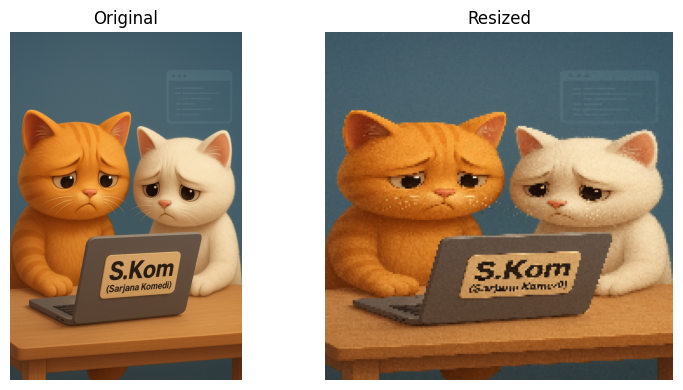

In [187]:
# Melakukan perubahan ukuran pada gambar (resizing)
img_resized = cv2.resize(img, (200, 200))
img_resized_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)

# Plot hasil
fig, axs = plt.subplots(1, 2, figsize=(8, 4))

# Original
axs[0].imshow(img_rgb)
axs[0].set_title("Original")
axs[0].axis("off")

# Cropped
axs[1].imshow(img_resized_rgb)
axs[1].set_title("Resized")
axs[1].axis("off")

plt.tight_layout()
plt.show()

### 3. Crop (Memotong Gambar)
Crop adalah proses memotong bagian tertentu dari gambar, seperti memperbesar objek tertentu atau menghilangkan latar belakang yang tidak diperlukan.

**Cara Kerja:**
- Gambar direpresentasikan sebagai array numpy dengan format `[height, width, channels]`.
- Crop dilakukan dengan slicing array numpy:
  - `cropped_image = image[y1:y2, x1:x2]`
  - `y1`, `y2` adalah batas vertikal, dan `x1`, `x2` adalah batas horizontal.


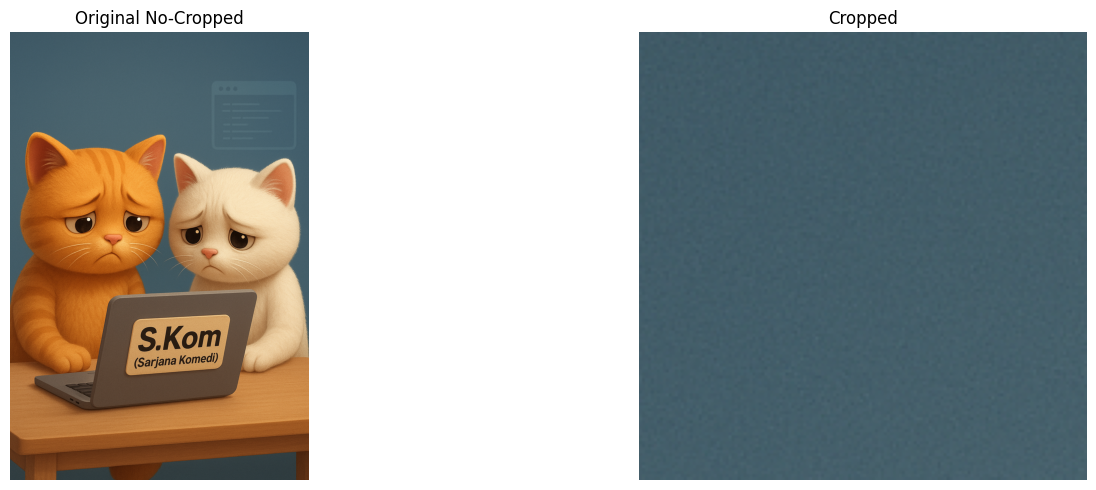

In [188]:
# Melakukan pemotongan
img_cropped_original = img[50:200, 50:200] 

# Plot gambar
fig, axs = plt.subplots(1, 2, figsize=(17, 5))

# Original no Crop
axs[0].imshow(img_rgb)
axs[0].set_title('Original No-Cropped')
axs[0].axis('off')

# Original cropped image
axs[1].imshow(cv2.cvtColor(img_cropped_original, cv2.COLOR_BGR2RGB))
axs[1].set_title('Cropped')
axs[1].axis('off')

plt.tight_layout()
plt.show()


**Pertanyaan:** Mengapa gambar *crop* original memotong bagian background dari gambar?

*Hint! Perhatikan cara kerja OpenCV melakukan koordinat gambar* 

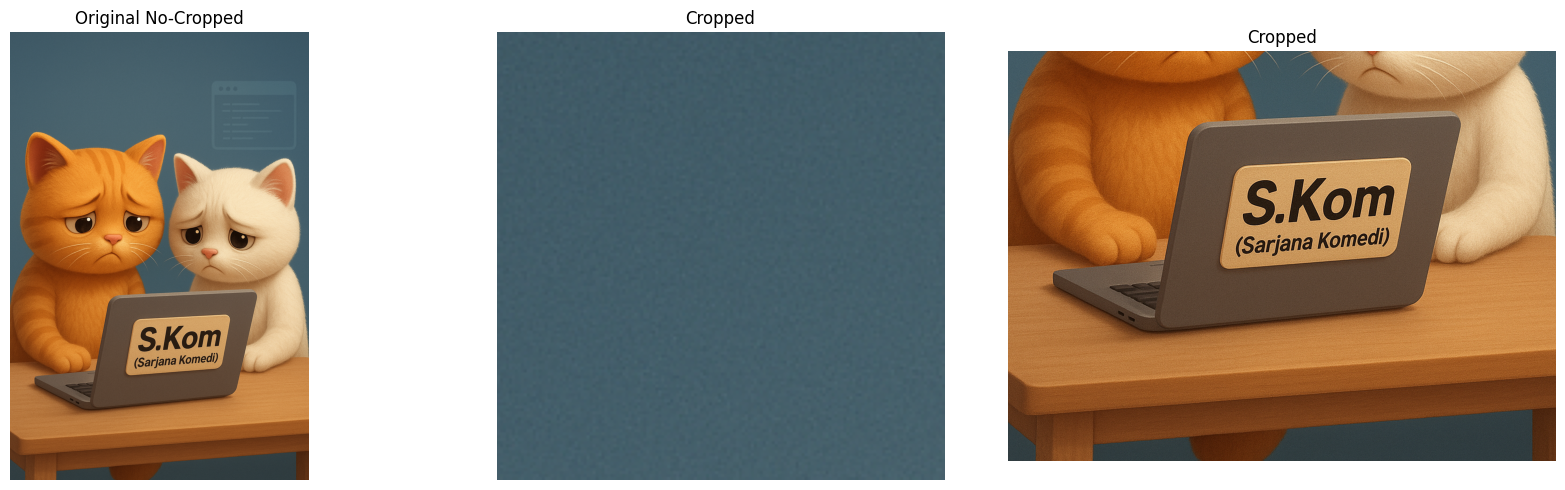

In [189]:
img_cropped_modification = img[img.shape[0]//2:, :]

# Plot 
fig, axs = plt.subplots(1, 3, figsize=(17, 5))

# Original no Crop
axs[0].imshow(img_rgb)
axs[0].set_title('Original No-Cropped')
axs[0].axis('off')

# Original cropped image
axs[1].imshow(cv2.cvtColor(img_cropped_original, cv2.COLOR_BGR2RGB))
axs[1].set_title('Cropped')
axs[1].axis('off')

# Original cropped image modif
axs[2].imshow(cv2.cvtColor(img_cropped_modification, cv2.COLOR_BGR2RGB))
axs[2].set_title('Cropped')
axs[2].axis('off')

plt.tight_layout()
plt.show()

# Konsep 2: Modifikasi Piksel dan Transformasi Geometris

Transformasi geometris meliputi translasi (menggeser), rotasi (memutar), dan scaling (mengubah ukuran).

- **Translasi:** Menggeser posisi gambar.
- **Rotasi:** Memutar gambar pada sudut tertentu.
- **Scaling:** Mengubah ukuran gambar.

Semua transformasi ini dapat direpresentasikan dengan matriks transformasi.

## Bermain dengan Pixel Value

Sebuah gambar digital tersusun atas nilai-nilai warna **RGB** yang disusun dalam baris dan kolom.  
Setiap piksel memiliki tiga komponen warna (Red, Green, Blue), dan masing-masing bernilai antara **0–255**.

**Mengapa 0–255?**
- Karena gambar umumnya disimpan dalam format **8-bit per channel**.  
- Setiap channel memiliki 8 bit (2⁸ = 256 kemungkinan nilai), sehingga rentang nilainya adalah 0–255.  
- Nilai `0` mewakili intensitas terendah (hitam), sedangkan `255` mewakili intensitas tertinggi (putih).  

Untuk lebih jelasnya, mari kita lihat isi **pixel value** pada gambar.  
Langkah pertama adalah mengecek atribut `.shape` dari gambar tersebut.  
`shape` adalah properti array **NumPy** yang menunjukkan dimensi array, misalnya `(tinggi, lebar, channel)`.  

Shape img2_rgb: (1024, 1536, 3)
Tinggi gambar: 1024 piksel
Lebar gambar: 1536 piksel
Jumlah channel: 3 (RGB)


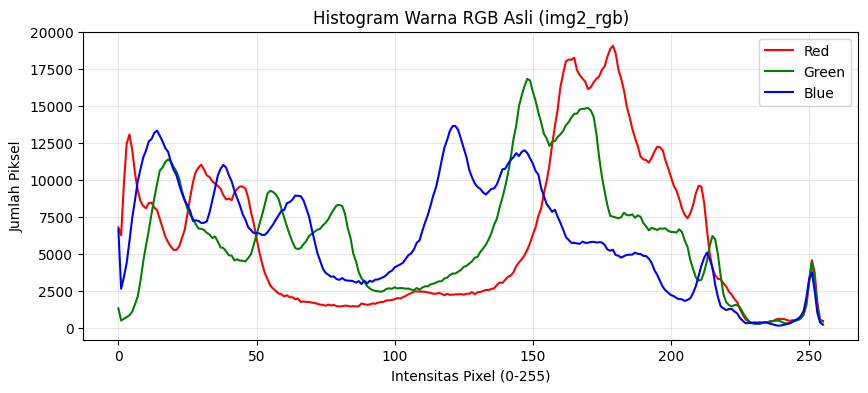

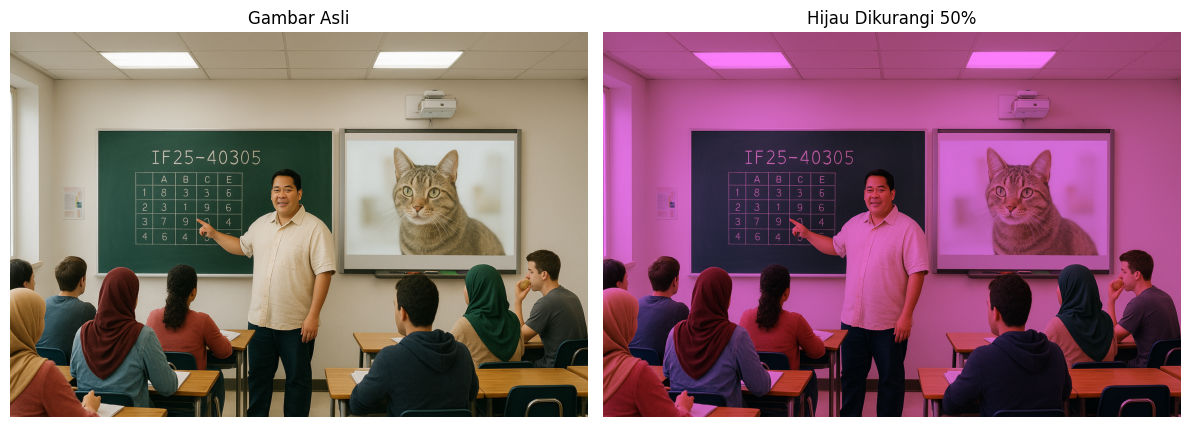

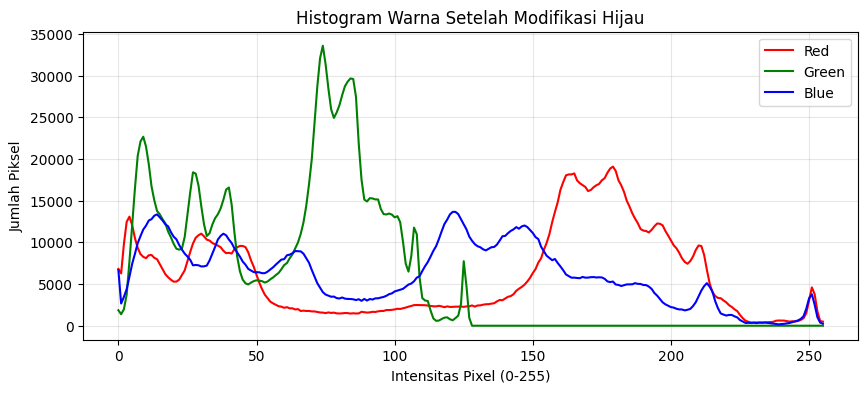


=== Penjelasan cv2.calcHist ===
cv2.calcHist([gambar], [channel], mask, [bins], [range])
- [gambar]: gambar input dalam list
- [channel]: channel yang ingin dihitung (0=R, 1=G, 2=B)
- mask: None berarti semua piksel dihitung
- [bins]: jumlah interval histogram (256 untuk 0-255)
- [range]: rentang nilai piksel [0,256)


In [ ]:
# Mengecek shape dari gambar
print("Shape img2_rgb:", img2_rgb.shape)  # (tinggi, lebar, channel)
print("Tinggi gambar:", img2_rgb.shape[0], "piksel")
print("Lebar gambar:", img2_rgb.shape[1], "piksel")
print("Jumlah channel:", img2_rgb.shape[2], "(RGB)")

# Modifikasi: Kurangi intensitas warna hijau (G) menjadi setengah
img2_mod = img2_rgb.copy()
img2_mod[:,:,1] = (img2_mod[:,:,1] * 0.5).astype(np.uint8)

# Buat layout 2x2
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

colors = ('r','g','b')
labels = ('Red','Green','Blue')

# Gambar Asli
axs[0,0].imshow(img2_rgb)
axs[0,0].set_title(f"Gambar Asli\nShape: {img2_rgb.shape}", fontsize=11)
axs[0,0].axis('off')

# Histogram Asli
for i, (col, label) in enumerate(zip(colors, labels)):
    hist = cv2.calcHist([img2_rgb], [i], None, [256], [0,256])
    axs[0,1].plot(hist, color=col, label=label)
axs[0,1].set_title("Histogram RGB Asli", fontsize=11)
axs[0,1].set_xlabel("Intensitas Pixel (0-255)")
axs[0,1].set_ylabel("Jumlah Piksel")
axs[0,1].legend()
axs[0,1].grid(True, alpha=0.3)

# Gambar Modifikasi
axs[1,0].imshow(img2_mod)
axs[1,0].set_title(f"Hijau Dikurangi 50%\nShape: {img2_mod.shape}", fontsize=11)
axs[1,0].axis('off')

# Histogram Modifikasi
for i, (col, label) in enumerate(zip(colors, labels)):
    hist = cv2.calcHist([img2_mod], [i], None, [256], [0,256])
    axs[1,1].plot(hist, color=col, label=label)
axs[1,1].set_title("Histogram RGB Setelah Modifikasi", fontsize=11)
axs[1,1].set_xlabel("Intensitas Pixel (0-255)")
axs[1,1].set_ylabel("Jumlah Piksel")
axs[1,1].legend()
axs[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Penjelasan calcHist
print("\n=== Penjelasan cv2.calcHist ===")
print("cv2.calcHist([gambar], [channel], mask, [bins], [range])")
print("- [gambar]: gambar input dalam list")
print("- [channel]: channel yang ingin dihitung (0=R, 1=G, 2=B)")
print("- mask: None berarti semua piksel dihitung")
print("- [bins]: jumlah interval histogram (256 untuk 0-255)")
print("- [range]: rentang nilai piksel [0,256)")


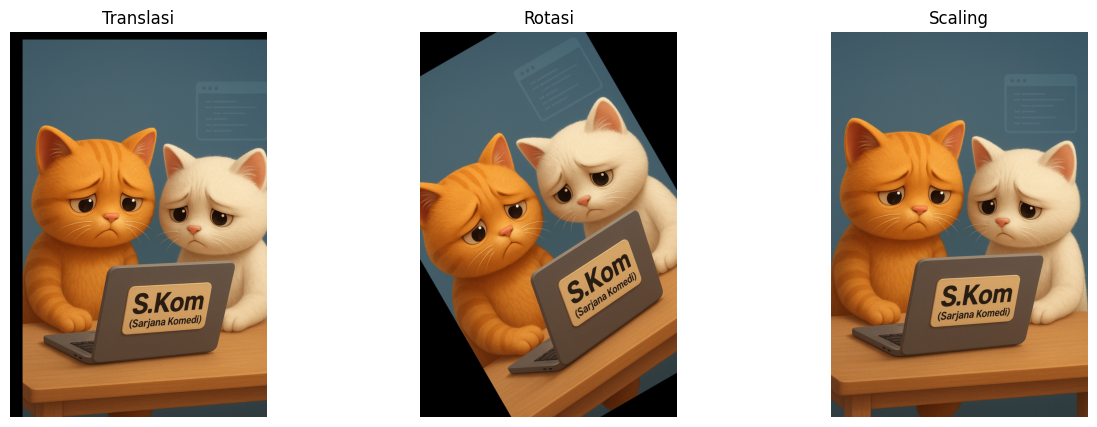

In [191]:
# Demo transformasi: translasi, rotasi, scaling
rows, cols = img_rgb.shape[:2]

# Translasi
M_trans = np.float32([[1, 0, 50], [0, 1, 30]])  # Geser 50px kanan, 30px bawah
img_trans = cv2.warpAffine(img_rgb, M_trans, (cols, rows))

# Rotasi
M_rot = cv2.getRotationMatrix2D((cols/2, rows/2), 30, 1)  # Rotasi 30 derajat
img_rot = cv2.warpAffine(img_rgb, M_rot, (cols, rows))

# Scaling
img_scale = cv2.resize(img_rgb, None, fx=1.5, fy=1.5)

# Tampilkan hasil
fig, axs = plt.subplots(1,3, figsize=(15,5))
axs[0].imshow(img_trans); axs[0].set_title('Translasi')
axs[1].imshow(img_rot); axs[1].set_title('Rotasi')
axs[2].imshow(img_scale); axs[2].set_title('Scaling')
for ax in axs: ax.axis('off')
plt.show()

# Praktik 2: Transformasi & Anotasi

Pada sesi ini, kita akan memutar gambar 45 derajat tanpa terpotong, menggeser objek, dan menambahkan anotasi visual.

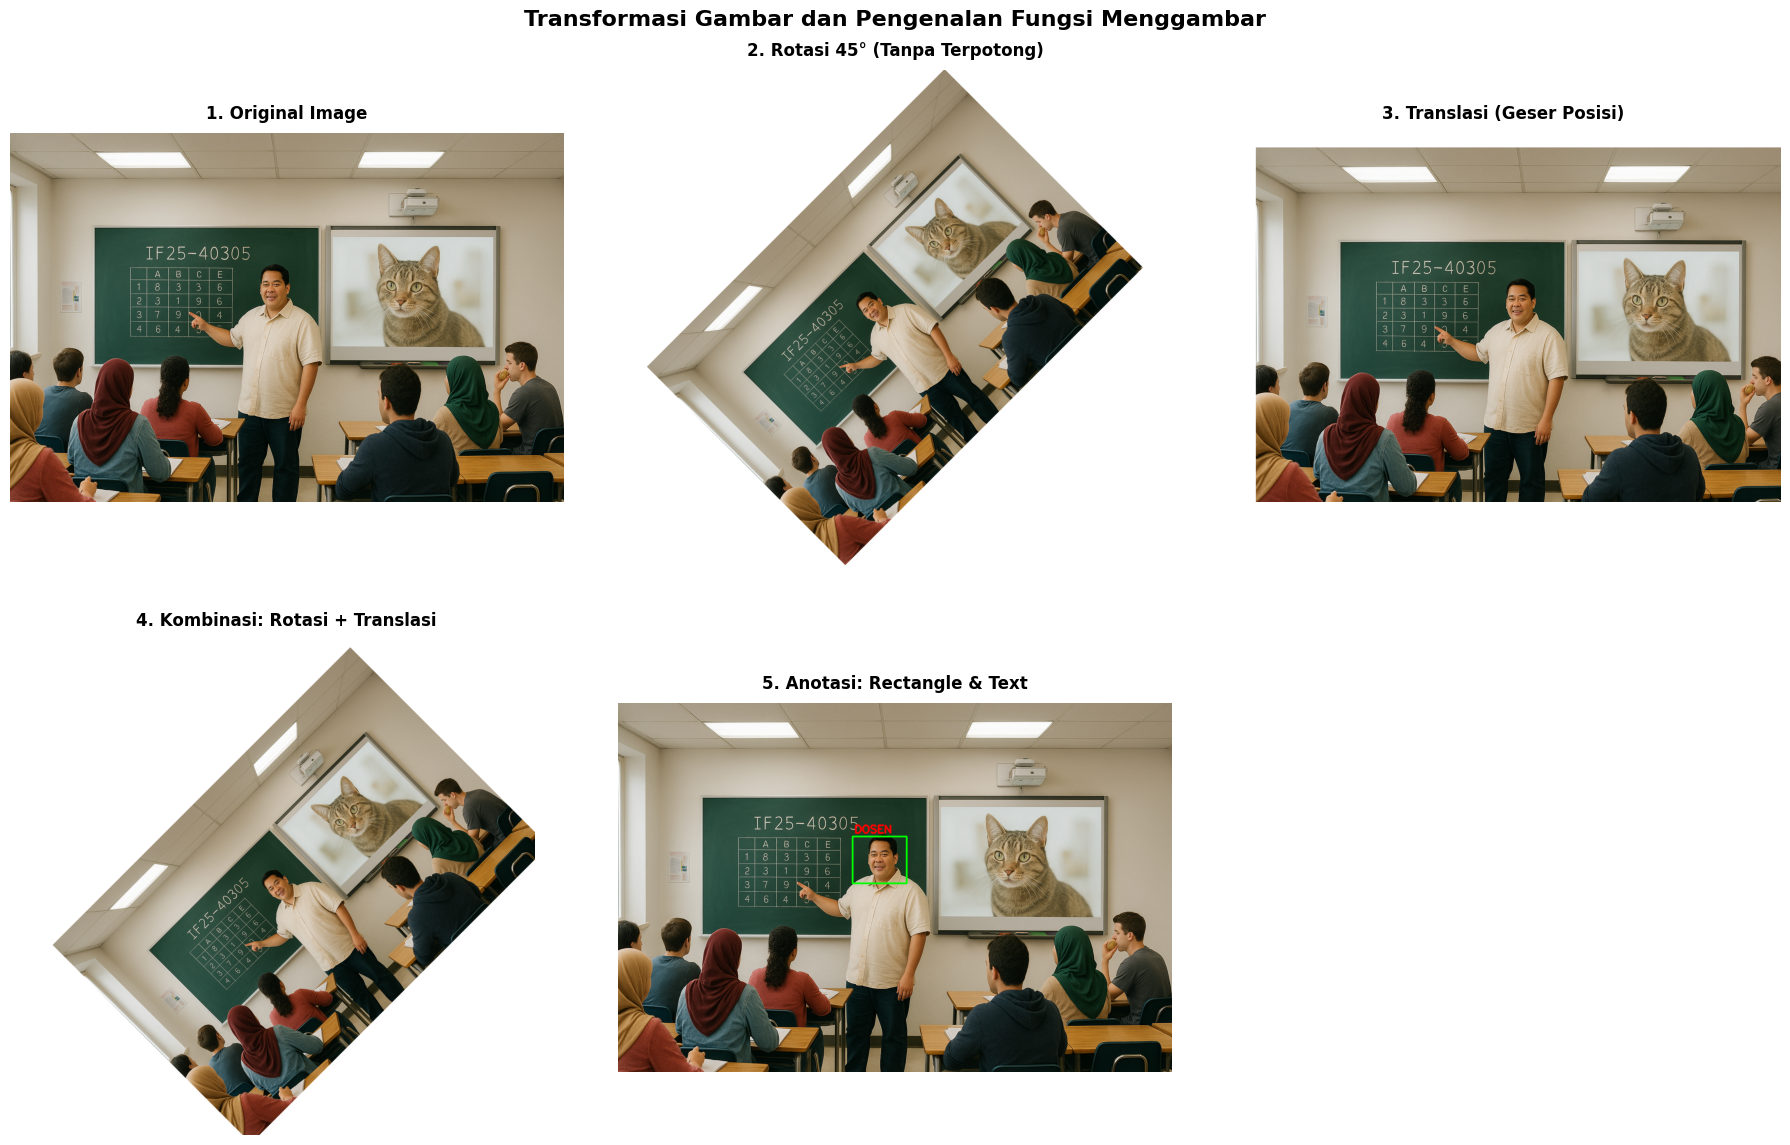

PARAMETER YANG DIGUNAKAN:
• Rotasi: 45° dengan canvas baru 1810x1810 px
• Translasi: geser (80, 40) pixel
• Rectangle: koordinat (650,370) ke (800,500) - hijau, tebal 4px
• Text: 'DOSEN' pada posisi (655,360) - merah, ukuran 1.0
• Background: putih untuk semua transformasi


In [192]:
# Pastikan img2_rgb sudah ada (format RGB) 
rows, cols = img2_rgb.shape[:2] 

# Original Image 
img_original = img2_rgb.copy()

# Rotasi 45 derajat TANPA TERPOTONG 
# Hitung ukuran canvas baru agar gambar tidak terpotong
angle = 45
M = cv2.getRotationMatrix2D((cols/2, rows/2), angle, 1) 

# Hitung dimensi baru
cos = np.abs(M[0, 0]) 
sin = np.abs(M[0, 1]) 
new_width = int((rows * sin) + (cols * cos)) 
new_height = int((rows * cos) + (cols * sin)) 

# Adjust translation untuk menempatkan gambar di tengah canvas baru
M[0, 2] += (new_width / 2) - cols/2 
M[1, 2] += (new_height / 2) - rows/2 

# Rotasi dengan background putih
img_rotated = cv2.warpAffine(img2_rgb, M, (new_width, new_height), 
                            borderValue=(255, 255, 255))

# 3Translasi (Menggeser Posisi Objek) 
# Matrix translasi: geser 80 pixel ke kanan, 40 pixel ke bawah
shift_x, shift_y = 80, 40
M_translation = np.float32([[1, 0, shift_x], [0, 1, shift_y]])   
img_translated = cv2.warpAffine(img2_rgb, M_translation, (cols, rows), 
                               borderValue=(255, 255, 255))

# Kombinasi: Rotasi + Translasi 
# Rotasi terlebih dahulu, lalu translasi
img_combo = cv2.warpAffine(img_rotated, 
                          np.float32([[1, 0, 50], [0, 1, 30]]), 
                          (new_width, new_height), 
                          borderValue=(255, 255, 255))

# Anotasi dengan Rectangle dan Text 
img_annotated = img2_rgb.copy() 

# Tambahkan rectangle (kotak)
cv2.rectangle(img_annotated, (650, 370), (800, 500), (0, 255, 0), 4)  # Hijau tebal

# Tambahkan text
cv2.putText(img_annotated, 'DOSEN', (655, 360), cv2.FONT_HERSHEY_SIMPLEX,  
            1.0, (255, 0, 0), 3)  # Merah tebal


# Anotasi pada Gambar yang Sudah Ditransformasi 
img_final = img_translated.copy()
# Tambahkan anotasi pada hasil translasi
cv2.rectangle(img_final, (650+shift_x, 370+shift_y), (800+shift_x, 500+shift_y), 
              (0, 255, 0), 4)
cv2.putText(img_final, 'TRANSFORMED', (655+shift_x, 360+shift_y), 
            cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 0, 0), 3)

# PLOT 2x3 Layout 
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Transformasi Gambar dan Pengenalan Fungsi Menggambar', 
             fontsize=16, fontweight='bold', y=0.95)

# Baris pertama
axes[0,0].imshow(img_original) 
axes[0,0].set_title('1. Original Image', fontsize=12, fontweight='bold', pad=10) 
axes[0,0].axis('off') 

axes[0,1].imshow(img_rotated) 
axes[0,1].set_title('2. Rotasi 45° (Tanpa Terpotong)', fontsize=12, fontweight='bold', pad=10) 
axes[0,1].axis('off') 

axes[0,2].imshow(img_translated) 
axes[0,2].set_title('3. Translasi (Geser Posisi)', fontsize=12, fontweight='bold', pad=10) 
axes[0,2].axis('off') 

# Baris kedua
axes[1,0].imshow(img_combo) 
axes[1,0].set_title('4. Kombinasi: Rotasi + Translasi', fontsize=12, fontweight='bold', pad=10) 
axes[1,0].axis('off') 

axes[1,1].imshow(img_annotated) 
axes[1,1].set_title('5. Anotasi: Rectangle & Text', fontsize=12, fontweight='bold', pad=10) 
axes[1,1].axis('off') 

axes[1,2].axis('off') 

# Penyesuaian layout
plt.tight_layout()
plt.subplots_adjust(top=0.90, hspace=0.15, wspace=0.1)
plt.show()

# Informasi Parameter 
print("=" * 60)
print("PARAMETER YANG DIGUNAKAN:")
print("=" * 60)
print(f"• Rotasi: {angle}° dengan canvas baru {new_width}x{new_height} px")
print(f"• Translasi: geser ({shift_x}, {shift_y}) pixel")
print(f"• Rectangle: koordinat (650,370) ke (800,500) - hijau, tebal 4px")
print(f"• Text: 'DOSEN' pada posisi (655,360) - merah, ukuran 1.0")
print("• Background: putih untuk semua transformasi")
print("=" * 60)

**Penjelasan**
* OpenCV menggunakan fungsi `cv2.getRotationMatrix2D()` untuk membuat matriks rotasi 2D berdasarkan pusat, sudut, dan skala.
* Fungsi `cv2.warpAffine()` digunakan untuk menerapkan transformasi (rotasi, translasi, kombinasi) ke gambar dengan parameter matriks transformasi dan ukuran canvas baru.
* Translasi dibuat dengan matriks manual `np.float32([[1, 0, shift_x], [0, 1, shift_y]])` untuk menggeser posisi gambar.
* Fungsi `cv2.rectangle()` digunakan untuk menggambar kotak pada gambar dengan menentukan koordinat sudut, warna, dan ketebalan garis.
* Fungsi `cv2.putText()` digunakan untuk menambahkan teks pada gambar dengan menentukan posisi, jenis font, ukuran, warna, dan ketebalan huruf.
